In [2]:
import os
from sklearn.pipeline import Pipeline
from model_class.feature_builder import FeatureBuilder
from model_class.feature_builder_transformer import FeatureBuilderTransformer
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve


### 1. Import data

In [3]:
# Get the current directory
current_directory = os.getcwd()

# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_training_data.csv"
df_train = pd.read_csv(file, header=0)
y_train = df_train['evil']
X_train = df_train.drop(columns=['sus', 'evil'])

# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_testing_data.csv"
df_test = pd.read_csv(file, header=0)
y_test = df_test['evil']
X_test = df_test.drop(columns=['sus', 'evil'])

# Get the source file path
file_path = f'{current_directory}/datasets/raw'
file = f"{file_path}/labelled_validation_data.csv"
df_validation = pd.read_csv(file, header=0)
y_validation = df_validation['evil']
X_validation = df_validation.drop(columns=['sus', 'evil'])

### 2. build features

In [ ]:
scale_cols = [
    "processId_freq",
    "threadId_freq",
    "parentProcessId_freq",
    "userId_freq",
    "mountNamespace_freq",
    "eventId_freq",
    "stackAddresses_len",
    "returnValue",
    "argsNum",
    "stackAddresses_jump_std"
]

passthrough_cols = [
    # "hostName_hash",
    # "processName_hash",
    # "parentProcessName_hash",
    "is_system_process",
    "is_parent_system_process",
    "userId_binary",
    "parentUserId_binary",
    "same_user_as_parent",
    "same_process_name_as_parent",
    "stackAddresses_unique_ratio",
    "returnValue_is_error",
    "args_has_path",
    "mountNamespace_binary"
]



scaler = ColumnTransformer(
    transformers=[
        ("scale", RobustScaler(), scale_cols),
        ("pass", "passthrough", passthrough_cols),
    ]
)


1. Isolation Forest

In [ ]:
model = Pipeline([
    ("features", FeatureBuilderTransformer(FeatureBuilder(), return_numpy=False)),
    ("scaler", scaler),
    ("iforest", IsolationForest(
            n_estimators=100,
            contamination=0.001,
            max_features=0.7,
            random_state=2000
        ))

])

In [ ]:
# Perform fit on X _train and returns labels for y_pred.
y_pred_train = model.fit_predict(X_train)

# Perform fit on X _train and returns labels for y_pred.
y_pred_validation= model.predict(X_validation)

# Perform fit on X _train and returns labels for y_pred.
y_pred_test = model.predict(X_test)

763144 rows before feature engineering
763144 rows after frequency encoding
763144 rows after merging parent process info
763144 rows after processing parent and child process info and relationship
763144 rows after processing stackAddresses info
763144 rows after processing arg info


### Model Evaluation

In [15]:

def evaluate_model(y_true, y_pred, dataset_type="Dataset"):
    # Returns -1 for outliers and 1 for inliers.
    # change -1 to 0:
    y_pred = np.where(y_pred == -1, 1, 0)

    # Get unique values and their counts in y_true
    unique_values, counts = np.unique(y_true, return_counts=True)
    print(f"y_true_{dataset_type} Unique values: {unique_values}")
    print(f"y_true_{dataset_type} Counts of each value: {counts}")

    # Get unique values and their counts in y_pred
    unique_values, counts = np.unique(y_pred, return_counts=True)
    print(f"y_pred_{dataset_type} Unique values: {unique_values}")
    print(f"y_pred_{dataset_type} Counts of each value: {counts}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Inlier", "Outlier"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {dataset_type}')
    plt.show()

    # ROC AUC Score
    roc_auc = roc_auc_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_pred)

    print(f"False Positive Rate: {fpr}")
    print(f"True Positive Rate: {tpr}")
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic for {dataset_type}')
    plt.legend(loc="lower right")
    plt.show()

y_true_Training Dataset Unique values: [0]
y_true_Training Dataset Counts of each value: [763144]
y_pred_Training Dataset Unique values: [0 1]
y_pred_Training Dataset Counts of each value: [763067     77]
[[763067     77]
 [     0      0]]


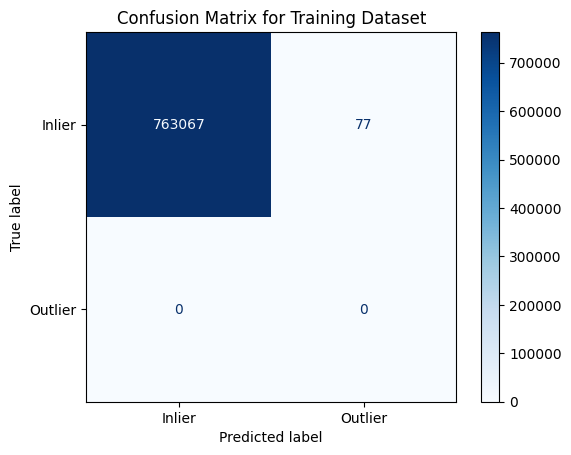

False Positive Rate: [0.00000000e+00 1.00898389e-04 1.00000000e+00]
True Positive Rate: [nan nan nan]


/Users/cheesecake/.pyenv/versions/anamoly-detection/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/cheesecake/.pyenv/versions/anamoly-detection/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


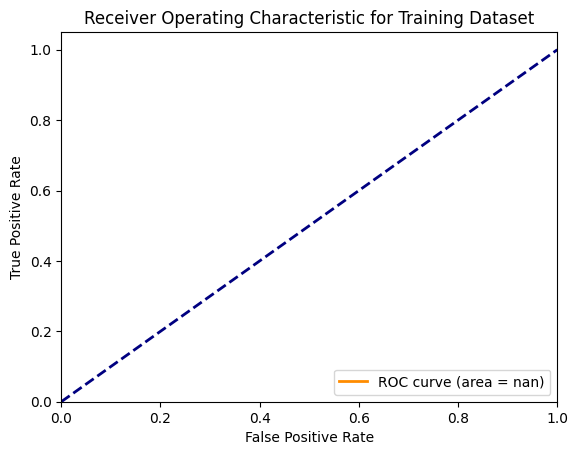

y_true_Validation Dataset Unique values: [0]
y_true_Validation Dataset Counts of each value: [188967]
y_pred_Validation Dataset Unique values: [0 1]
y_pred_Validation Dataset Counts of each value: [178453  10514]
[[178453  10514]
 [     0      0]]


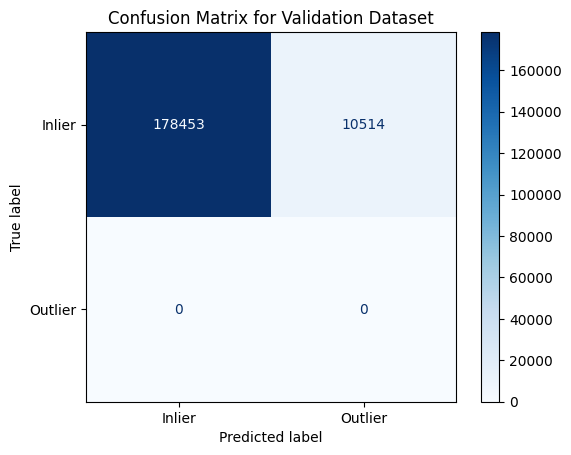

/Users/cheesecake/.pyenv/versions/anamoly-detection/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/cheesecake/.pyenv/versions/anamoly-detection/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


False Positive Rate: [0.         0.05563934 1.        ]
True Positive Rate: [nan nan nan]


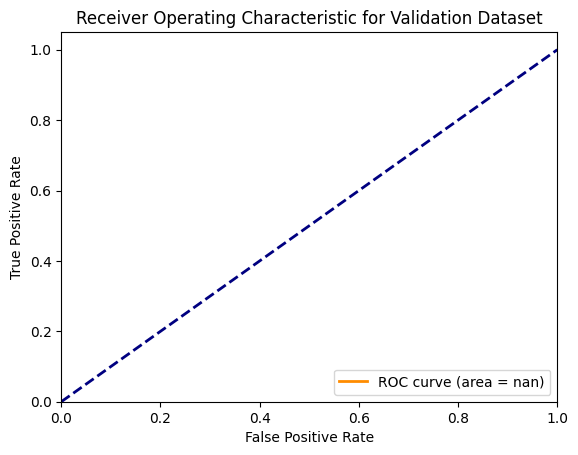

y_true_Test Dataset Unique values: [0 1]
y_true_Test Dataset Counts of each value: [ 30535 158432]
y_pred_Test Dataset Unique values: [0 1]
y_pred_Test Dataset Counts of each value: [172459  16508]
[[ 15641  14894]
 [156818   1614]]


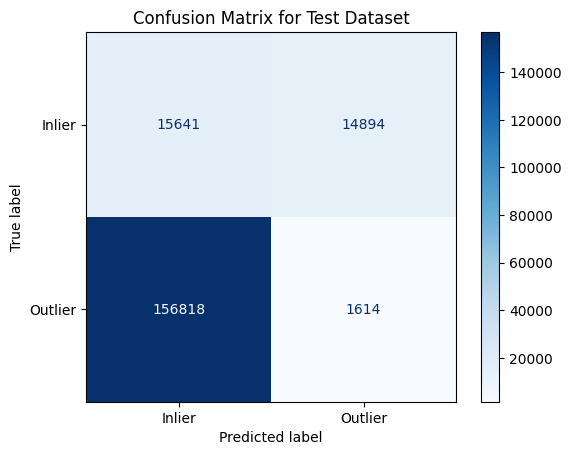

False Positive Rate: [0.         0.48776813 1.        ]
True Positive Rate: [0.         0.01018734 1.        ]


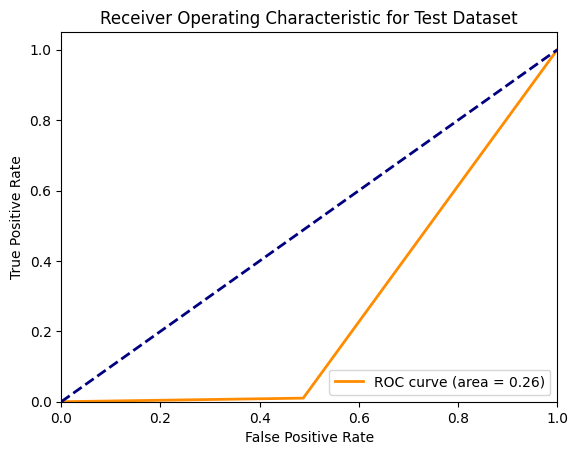

In [16]:
evaluate_model(y_train, y_pred_train, dataset_type="Training Dataset")
evaluate_model(y_validation, y_pred_validation, dataset_type="Validation Dataset")
evaluate_model(y_test, y_pred_test, dataset_type="Test Dataset")

188967 rows before feature engineering
188967 rows after frequency encoding
188967 rows after merging parent process info
188967 rows after processing parent and child process info and relationship
188967 rows after processing stackAddresses info
188967 rows after processing arg info


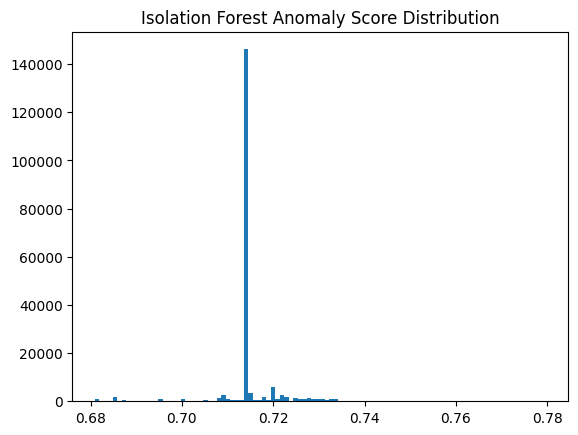

In [9]:
anomaly_scores = model.score_samples(X_test)

anomaly_scores = -anomaly_scores  # Invert scores so that higher values indicate more anomalous instances
plt.hist(anomaly_scores, bins=100)
plt.title("Isolation Forest Anomaly Score Distribution")
plt.show()